# Ensemble Methods
### Interactive Notebook for AI/ML Interview Preparation

📺 **Video Lecture:** [https://youtu.be/m06esXrTdIc](https://youtu.be/m06esXrTdIc)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Single Tree vs Random Forest

In [2]:
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)

tree = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

tree_scores = cross_val_score(tree, X, y, cv=5)
rf_scores = cross_val_score(rf, X, y, cv=5)

print(f'Decision Tree: {tree_scores.mean():.3f} ± {tree_scores.std():.3f}')
print(f'Random Forest: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')
print(f'\nForest reduces variance through averaging many diverse trees!')

Decision Tree: 0.862 ± 0.021
Random Forest: 0.910 ± 0.030

Forest reduces variance through averaging many diverse trees!


---
## 2. Bagging from Scratch

In [3]:
# Manual bagging: bootstrap samples → train trees → average
n_bags = 20
predictions = []
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

for i in range(n_bags):
    # Bootstrap sample
    idx = np.random.choice(len(X_tr), len(X_tr), replace=True)
    tree = DecisionTreeClassifier(random_state=i).fit(X_tr[idx], y_tr[idx])
    predictions.append(tree.predict(X_te))

# Majority vote
ensemble_pred = np.round(np.mean(predictions, axis=0)).astype(int)
single_acc = (predictions[0] == y_te).mean()
ensemble_acc = (ensemble_pred == y_te).mean()
print(f'Single tree accuracy: {single_acc:.3f}')
print(f'Bagged ensemble ({n_bags} trees): {ensemble_acc:.3f}')

Single tree accuracy: 0.880
Bagged ensemble (20 trees): 0.913


---
## 3. Gradient Boosting — Sequential Residual Fitting

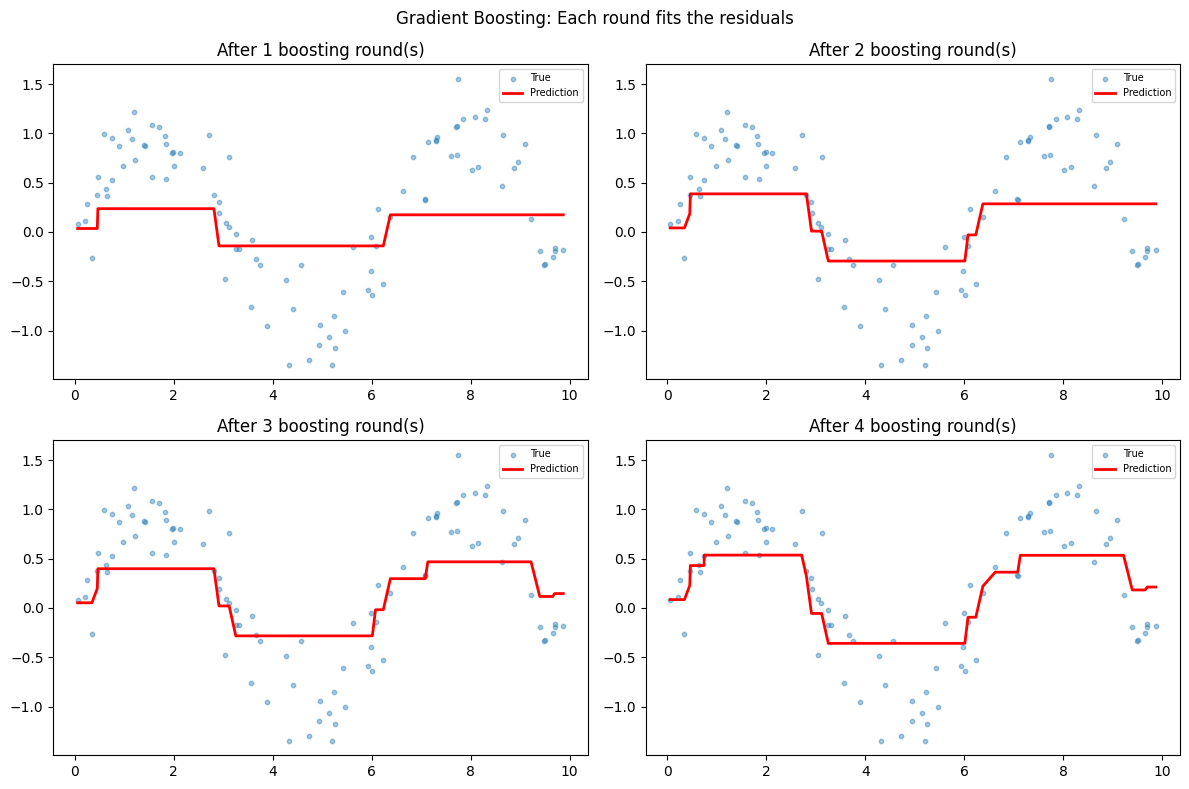

In [4]:
# Visualize gradient boosting on regression
np.random.seed(42)
X_gb = np.sort(np.random.uniform(0, 10, 100))
y_gb = np.sin(X_gb) + np.random.normal(0, 0.3, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
prediction = np.zeros_like(y_gb)
lr_boost = 0.3

for i, ax in enumerate(axes.flat):
    residual = y_gb - prediction
    tree = DecisionTreeClassifier if False else __import__('sklearn.tree', fromlist=['DecisionTreeRegressor']).DecisionTreeRegressor
    stump = tree(max_depth=2).fit(X_gb.reshape(-1,1), residual)
    update = stump.predict(X_gb.reshape(-1,1))
    prediction += lr_boost * update
    ax.scatter(X_gb, y_gb, s=10, alpha=0.4, label='True')
    ax.plot(X_gb, prediction, 'r-', linewidth=2, label='Prediction')
    ax.set_title(f'After {i+1} boosting round(s)')
    ax.legend(fontsize=7)
plt.suptitle('Gradient Boosting: Each round fits the residuals', fontsize=12)
plt.tight_layout(); plt.show()

---
## 4. Feature Importance Comparison

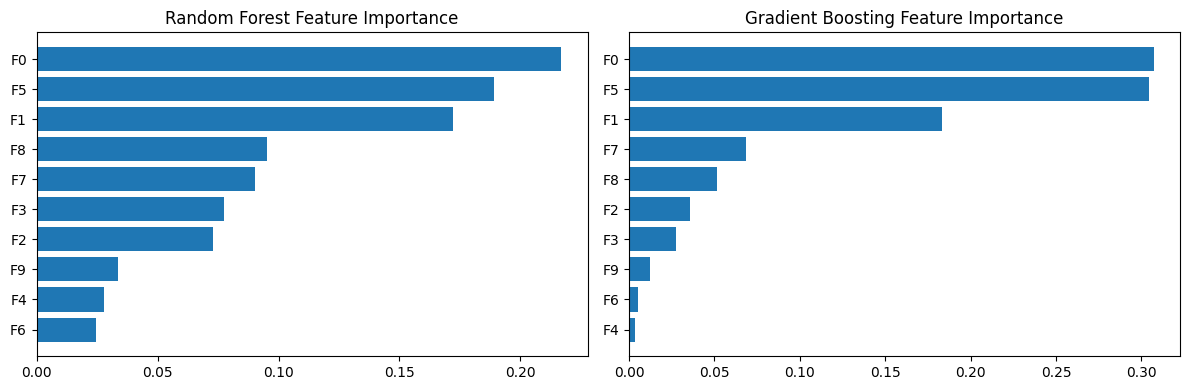

In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
features = [f'F{i}' for i in range(X.shape[1])]
for ax, model, name in zip(axes, [rf_model, gb_model], ['Random Forest', 'Gradient Boosting']):
    imp = model.feature_importances_
    idx = np.argsort(imp)
    ax.barh(range(len(imp)), imp[idx])
    ax.set_yticks(range(len(imp))); ax.set_yticklabels([features[i] for i in idx])
    ax.set_title(f'{name} Feature Importance')
plt.tight_layout(); plt.show()

---
## Key Interview Takeaways

1. **Bagging** (Random Forest) — reduces variance by averaging; trees built independently
2. **Boosting** (GBM, XGBoost) — reduces bias by sequential fitting; each tree corrects errors
3. **Random Forest** — more stable, less tuning; GBM — more powerful, more tuning
4. **Feature importance** — built into tree ensembles; compare across methods
5. **Stacking** — uses a meta-learner on base model predictions

---

<small><em>© 2026 AI Nirvana · Disclaimer: Provided as is. No liability assumed.</em></small>